# Experiment 9 — Truncation: Theoretical vs Empirical Optimal Threshold $c^*$

**Setup:** Control $X\sim\text{LogNormal}$, Treatment $Y=X+\tau(X)$.  
Drop observations above $c$: keep $\tilde{X}=X|X\le c$, $\tilde{Y}=Y|Y\le c$.

---
### Key derivation quantities (reverse hazard rate $r(c)=p(c)/F(c)$)

$$\mu'(c)=r(c)(c-\mu(c)),\qquad V'(c)=r(c)\bigl[(c-\mu(c))^2-V(c)\bigr]$$

where $\mu(c)=E[X|X\le c]$ and $V(c)=\text{Var}(X|X\le c)$.

---
### SNR and effective sample size

After truncation, each group retains $\approx N\cdot F(c)$ observations, so the SE of the difference is
$g(c)=\sqrt{2V(c)/(N\cdot F(c))}$.
Dropping the constant $\sqrt{N/2}$, we maximise:

$$\text{SNR}(c)=\frac{f(c)\,\sqrt{F(c)}}{\sqrt{V(c)}}, \qquad f(c)=E[Y|Y\le c]-E[X|X\le c]$$

---
### Theoretical FOC (first-order condition for $c^*$)

Setting $\frac{d}{dc}\text{SNR}=0$ and substituting:

$$\boxed{2\,f'(c^*)\,V(c^*)=f(c^*)\cdot r(c^*)\cdot\bigl[(c^*-\mu(c^*))^2-2\,V(c^*)\bigr]}$$

| Effect | $f(c)$ | $f'(c)$ | $\mu_Y(c)$, $r_Y(c)$ |
|---|---|---|---|
| Constant $\tau$ | $\mu(c{-}\tau)+\tau-\mu(c)$ | $r(c{-}\tau)[(c{-}\tau)-\mu(c{-}\tau)]-r(c)[c-\mu(c)]$ | $\mu(c{-}\tau)+\tau$,  $r(c{-}\tau)$ |
| Linear $\alpha$ | $(1{+}\alpha)\mu(c/(1{+}\alpha))-\mu(c)$ | $r(c/(1{+}\alpha))\bigl[c/(1{+}\alpha)-\mu(c/(1{+}\alpha))\bigr]-r(c)[c-\mu(c)]$ | $(1{+}\alpha)\mu(c/(1{+}\alpha))$,  $r(c/(1{+}\alpha))/(1{+}\alpha)$ |

> **Note on same-N assumption:** If instead of $N\cdot F(c)$ we assume N observations in both groups (no data loss),
> SNR simplifies to $f(c)/\sqrt{V(c)}$ and the FOC changes to
> $2f'V = f\cdot r\cdot[(c-\mu)^2 - V]$.  
> Under that formulation, **constant additive effects yield no interior $c^*$** (SNR is monotone decreasing),
> while linear effects still have an interior solution.  
> The effective-$N$ version used here is both theoretically consistent and matches the standard t-test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate, optimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Generate Skewed Dummy Data

Distribution: LogNormal(mu=0.5, sigma=0.9)
  X:  mean=2.474, std=2.748, median=1.653, 95th=7.282
  Y_const (τ=1.0):  mean=3.474
  Y_lin   (α=0.2): mean=2.969


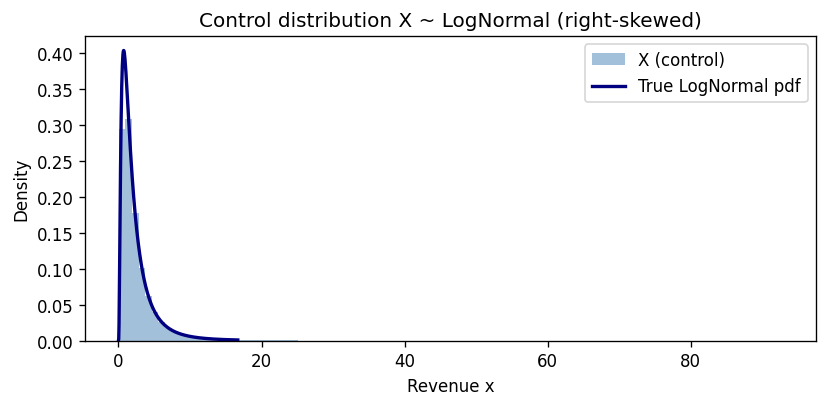

In [2]:
N = 100_000

# Log-normal — same as Experiment 8 for comparability
LOG_MU    = 0.5
LOG_SIGMA = 0.9
dist = stats.lognorm(s=LOG_SIGMA, scale=np.exp(LOG_MU))

X = dist.rvs(N)

TAU   = 1.0    # constant additive effect
ALPHA = 0.20   # linear multiplicative effect

Y_const = X + TAU
Y_lin   = (1 + ALPHA) * X

print(f"Distribution: LogNormal(mu={LOG_MU}, sigma={LOG_SIGMA})")
print(f"  X:  mean={X.mean():.3f}, std={X.std():.3f}, "
      f"median={np.median(X):.3f}, 95th={np.percentile(X,95):.3f}")
print(f"  Y_const (τ={TAU}):  mean={Y_const.mean():.3f}")
print(f"  Y_lin   (α={ALPHA}): mean={Y_lin.mean():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(X, bins=100, density=True, alpha=0.5, color='steelblue', label='X (control)')
x_plot = np.linspace(0, np.percentile(X, 99.5), 400)
ax.plot(x_plot, dist.pdf(x_plot), 'navy', lw=2, label='True LogNormal pdf')
ax.set_xlabel('Revenue x'); ax.set_ylabel('Density')
ax.set_title('Control distribution X ~ LogNormal (right-skewed)')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Theoretical Functions for Truncation

In [3]:
# ── Base truncated moments of X ───────────────────────────────────────────────

def mu_trunc(c):
    """E[X | X≤c] = ∫₀ᶜ x p(x) dx / F(c)"""
    Fc = dist.cdf(c)
    if Fc < 1e-12:
        return 0.0
    num, _ = integrate.quad(lambda x: x * dist.pdf(x), 0, c, limit=200)
    return num / Fc

def V_trunc(c):
    """Var(X | X≤c) = E[X²|X≤c] − μ(c)²"""
    Fc = dist.cdf(c)
    if Fc < 1e-12:
        return 0.0
    m2, _ = integrate.quad(lambda x: x**2 * dist.pdf(x), 0, c, limit=200)
    mu = mu_trunc(c)
    return max(m2 / Fc - mu**2, 0.0)

def r(c):
    """Reverse hazard rate of X: p(c)/F(c)"""
    Fc = dist.cdf(c)
    return dist.pdf(c) / Fc if Fc > 1e-12 else 0.0

# ── Theoretical SNR with effective sample size N·F(c) ─────────────────────────
# SNR_eff(c) = f(c)·√F(c) / √V(c)
# FOC: 2f'(c)·V(c) = f(c)·r(c)·[(c−μ(c))² − 2V(c)]

def foc_residual(c, fc, fpc, mu_c, Vc, rc):
    """Generic FOC residual = 2f'V − f·r·[(c−μ)² − 2V]."""
    return 2 * fpc * Vc - fc * rc * ((c - mu_c)**2 - 2 * Vc)

# ── Constant effect τ ─────────────────────────────────────────────────────────
# Y=X+τ: Y≤c ⟺ X≤c−τ
# r_Y(c)=r(c−τ), μ_Y(c)=μ(c−τ)+τ

def f_trunc_const(c, tau=TAU):
    ct = max(c - tau, 1e-9)
    return mu_trunc(ct) + tau - mu_trunc(c)

def f_prime_trunc_const(c, tau=TAU):
    """f'(c) = r(c−τ)·[(c−τ)−μ(c−τ)] − r(c)·[c−μ(c)]"""
    ct = max(c - tau, 1e-9)
    return r(ct) * (ct - mu_trunc(ct)) - r(c) * (c - mu_trunc(c))

def foc_trunc_const(c, tau=TAU):
    if c <= tau or dist.cdf(c) < 1e-9:
        return -1.0
    mu_c = mu_trunc(c); Vc = V_trunc(c); rc = r(c)
    fc   = f_trunc_const(c, tau)
    fpc  = f_prime_trunc_const(c, tau)
    return foc_residual(c, fc, fpc, mu_c, Vc, rc)

def snr_trunc_theory_const(c, tau=TAU):
    Vc = V_trunc(c); Fc = dist.cdf(c)
    if Vc < 1e-12 or Fc < 1e-12:
        return 0.0
    return f_trunc_const(c, tau) * np.sqrt(Fc) / np.sqrt(Vc)

# ── Linear effect α (Y=(1+α)X) ────────────────────────────────────────────────
# Y≤c ⟺ X≤c/(1+α)
# r_Y(c)=r(c/(1+α))/(1+α), μ_Y(c)=(1+α)·μ(c/(1+α))

def f_trunc_lin(c, alpha=ALPHA):
    return (1 + alpha) * mu_trunc(c / (1 + alpha)) - mu_trunc(c)

def f_prime_trunc_lin(c, alpha=ALPHA):
    """f'(c) = r(c/(1+α))·[c/(1+α)−μ(c/(1+α))] − r(c)·[c−μ(c)]"""
    cs = c / (1 + alpha)
    return r(cs) * (cs - mu_trunc(cs)) - r(c) * (c - mu_trunc(c))

def foc_trunc_lin(c, alpha=ALPHA):
    if dist.cdf(c) < 1e-9:
        return -1.0
    mu_c = mu_trunc(c); Vc = V_trunc(c); rc = r(c)
    fc   = f_trunc_lin(c, alpha)
    fpc  = f_prime_trunc_lin(c, alpha)
    return foc_residual(c, fc, fpc, mu_c, Vc, rc)

def snr_trunc_theory_lin(c, alpha=ALPHA):
    Vc = V_trunc(c); Fc = dist.cdf(c)
    if Vc < 1e-12 or Fc < 1e-12:
        return 0.0
    return f_trunc_lin(c, alpha) * np.sqrt(Fc) / np.sqrt(Vc)

print("Theoretical functions defined.")

Theoretical functions defined.


## 3. Find Theoretical $c^*$ via Root-Finding on FOC

In [4]:
c_scan = np.linspace(dist.ppf(0.40), dist.ppf(0.9995), 400)

print("Computing FOC residuals over grid (≈30 s due to numerical integration)...")
foc_scan_const = np.array([foc_trunc_const(c) for c in c_scan])
foc_scan_lin   = np.array([foc_trunc_lin(c)   for c in c_scan])
print("Done.")

def first_sign_change_bracket(vals, grid, direction='+to-'):
    """Find bracket where FOC changes sign from + to −."""
    for i in range(len(vals) - 1):
        if vals[i] > 0 and vals[i+1] < 0:
            return grid[i], grid[i+1]
    return None  # no interior optimum found

bracket_const = first_sign_change_bracket(foc_scan_const, c_scan)
bracket_lin   = first_sign_change_bracket(foc_scan_lin,   c_scan)

if bracket_const is not None:
    c_star_theory_const = optimize.brentq(
        foc_trunc_const, *bracket_const, xtol=1e-5)
    print(f"Theoretical c* — Constant (τ={TAU}):  {c_star_theory_const:.4f}")
    print(f"  FOC residual at c*: {foc_trunc_const(c_star_theory_const):.2e}")
else:
    c_star_theory_const = None
    print(f"Constant effect (τ={TAU}): NO interior c* — FOC is always negative.")
    print("  → SNR is monotone: signal decays faster than noise shrinks as c grows.")
    print("  → Optimal under this criterion: use the smallest meaningful threshold.")

if bracket_lin is not None:
    c_star_theory_lin = optimize.brentq(
        foc_trunc_lin, *bracket_lin, xtol=1e-5)
    print(f"Theoretical c* — Linear  (α={ALPHA}): {c_star_theory_lin:.4f}")
    print(f"  FOC residual at c*: {foc_trunc_lin(c_star_theory_lin):.2e}")
else:
    c_star_theory_lin = None
    print(f"Linear effect (α={ALPHA}): no interior c* found in grid.")

Computing FOC residuals over grid (≈30 s due to numerical integration)...
Done.
Theoretical c* — Constant (τ=1.0):  1.4001
  FOC residual at c*: 5.46e-10
Theoretical c* — Linear  (α=0.2): 22.8226
  FOC residual at c*: 1.93e-13


## 4. Empirical $c^*$ via Grid Search on Samples

In [5]:
c_grid = np.linspace(np.percentile(X, 40), np.percentile(X, 99.9), 300)

def snr_trunc_empirical(c, Xarr, Yarr):
    """
    SNR_eff = (mean(Y|Y≤c) − mean(X|X≤c)) / std(X|X≤c) · sqrt(F̂(c))
    Matches theoretical SNR_eff = f(c)·√F(c)/√V(c).
    """
    Xt = Xarr[Xarr <= c]
    Yt = Yarr[Yarr <= c]
    if len(Xt) < 5 or len(Yt) < 5:
        return 0.0
    f   = Yt.mean() - Xt.mean()
    v   = Xt.var(ddof=1)
    Fc  = len(Xt) / len(Xarr)          # empirical F(c)
    return f * np.sqrt(Fc) / np.sqrt(v) if v > 0 else 0.0

def tstat_trunc_empirical(c, Xarr, Yarr):
    """
    Standard two-sample t-statistic on truncated data.
    Uses actual truncated sample sizes (accounts for data loss naturally).
    """
    Xt = Xarr[Xarr <= c]
    Yt = Yarr[Yarr <= c]
    if len(Xt) < 5 or len(Yt) < 5:
        return 0.0
    t, _ = stats.ttest_ind(Yt, Xt, equal_var=True)
    return t

# Constant effect
snr_emp_const   = np.array([snr_trunc_empirical(c, X, Y_const)   for c in c_grid])
tstat_emp_const = np.array([tstat_trunc_empirical(c, X, Y_const) for c in c_grid])
c_star_snr_const   = c_grid[np.argmax(snr_emp_const)]
c_star_tstat_const = c_grid[np.argmax(tstat_emp_const)]

# Linear effect
snr_emp_lin   = np.array([snr_trunc_empirical(c, X, Y_lin)   for c in c_grid])
tstat_emp_lin = np.array([tstat_trunc_empirical(c, X, Y_lin) for c in c_grid])
c_star_snr_lin   = c_grid[np.argmax(snr_emp_lin)]
c_star_tstat_lin = c_grid[np.argmax(tstat_emp_lin)]

# Theoretical SNR curves
snr_theory_const = np.array([snr_trunc_theory_const(c) for c in c_scan])
snr_theory_lin   = np.array([snr_trunc_theory_lin(c)   for c in c_scan])

print(f"{'Method':<28} {'Constant τ='+str(TAU):>14} {'Linear α='+str(ALPHA):>14}")
print("-" * 58)
theory_c = f"{c_star_theory_const:.4f}" if c_star_theory_const else "boundary"
theory_l = f"{c_star_theory_lin:.4f}"   if c_star_theory_lin   else "boundary"
print(f"{'Theoretical FOC c*':<28} {theory_c:>14} {theory_l:>14}")
print(f"{'Empirical max-SNR_eff c*':<28} {c_star_snr_const:>14.4f} {c_star_snr_lin:>14.4f}")
print(f"{'Empirical max-t c*':<28} {c_star_tstat_const:>14.4f} {c_star_tstat_lin:>14.4f}")

Method                       Constant τ=1.0   Linear α=0.2
----------------------------------------------------------
Theoretical FOC c*                   1.4001        22.8226
Empirical max-SNR_eff c*             1.3964        22.9220
Empirical max-t c*                   2.4810        14.8290


## 5. Visualization

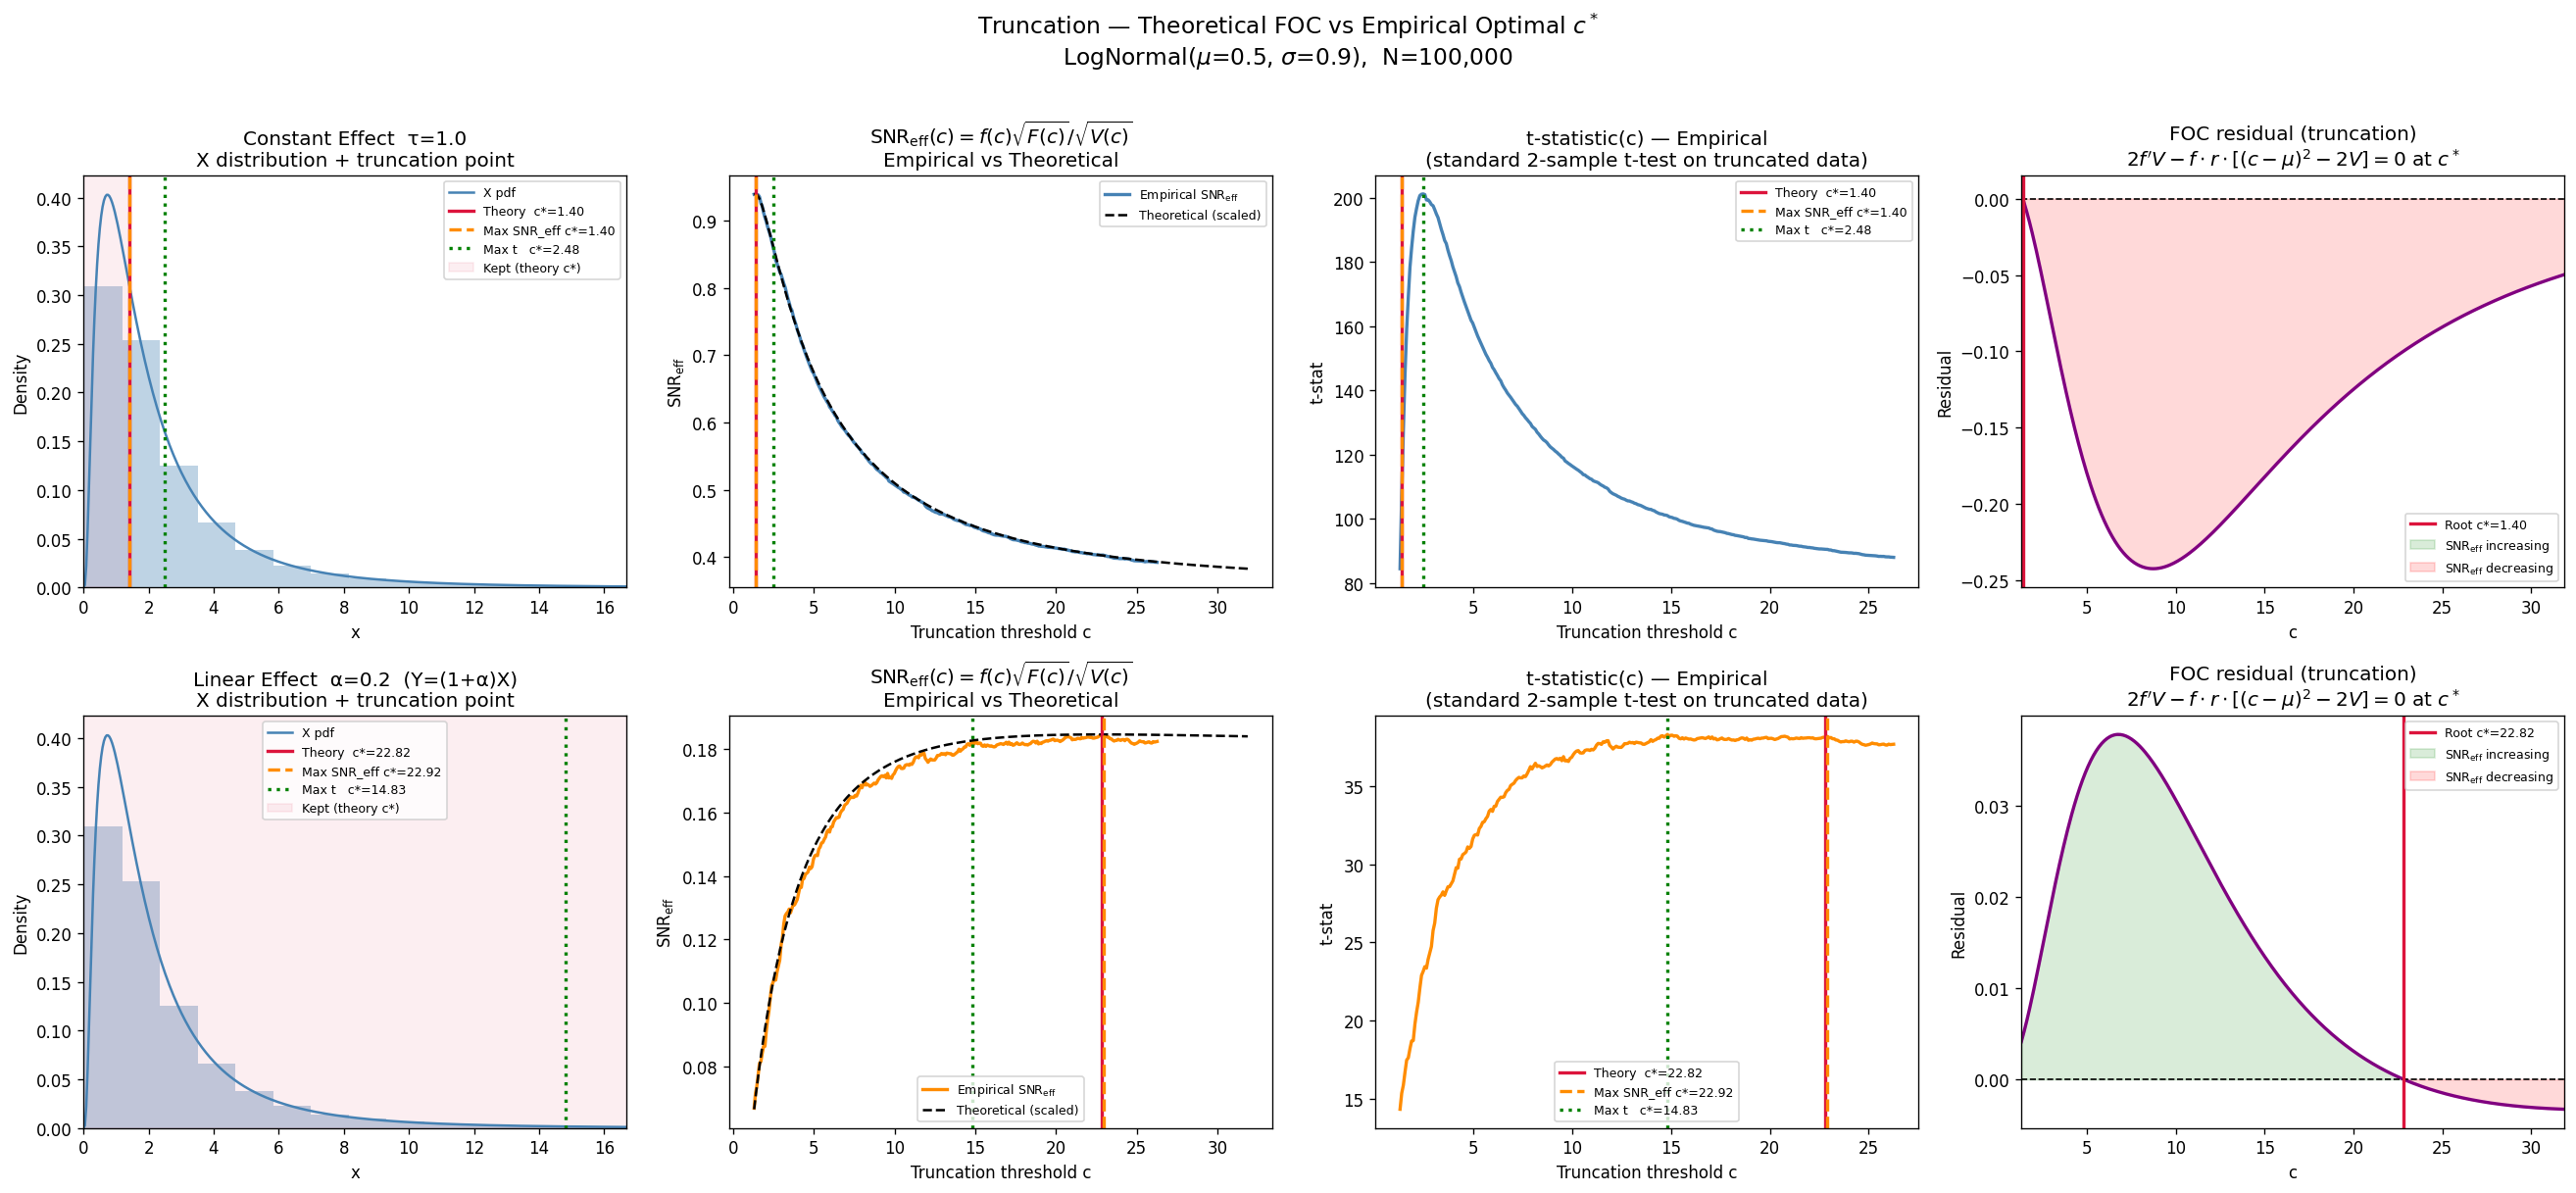

In [6]:
def plot_truncation_case(axes_row, X, c_grid, c_scan,
                         snr_emp, tstat_emp, snr_theory, foc_scan,
                         c_theory, c_snr, c_tstat,
                         title, row_color):
    ax_hist, ax_snr, ax_t, ax_foc = axes_row

    has_theory = c_theory is not None
    vlines = []
    if has_theory:
        vlines.append((c_theory, 'crimson', '-', f'Theory  c*={c_theory:.2f}'))
    vlines.append((c_snr,   'darkorange', '--', f'Max SNR_eff c*={c_snr:.2f}'))
    vlines.append((c_tstat, 'green',      ':',  f'Max t   c*={c_tstat:.2f}'))

    # ── Histogram ────────────────────────────────────────────────────
    x_plot = np.linspace(0, np.percentile(X, 99.5), 400)
    ax_hist.hist(X, bins=80, density=True, alpha=0.35, color='steelblue')
    ax_hist.plot(x_plot, dist.pdf(x_plot), 'steelblue', lw=1.5, label='X pdf')
    for cv, col, ls, lbl in vlines:
        ax_hist.axvline(cv, color=col, lw=2, linestyle=ls, label=lbl)
    if has_theory:
        ax_hist.axvspan(0, c_theory, alpha=0.07, color='crimson', label='Kept (theory c*)')
    ax_hist.set_xlim(0, np.percentile(X, 99.5))
    ax_hist.set_title(f'{title}\nX distribution + truncation point')
    ax_hist.set_xlabel('x'); ax_hist.set_ylabel('Density')
    ax_hist.legend(fontsize=7.5)

    # ── SNR_eff curves: empirical + theoretical ───────────────────────
    # Scale theoretical to match empirical magnitude for shape comparison
    theory_max = snr_theory.max()
    emp_max    = snr_emp.max()
    scale = emp_max / theory_max if theory_max > 0 else 1
    ax_snr.plot(c_grid, snr_emp,              color=row_color, lw=2,
                label='Empirical $\\text{SNR}_{\\text{eff}}$')
    ax_snr.plot(c_scan, snr_theory * scale,   color='black',   lw=1.5,
                linestyle='--', label='Theoretical (scaled)')
    for cv, col, ls, _ in vlines:
        ax_snr.axvline(cv, color=col, lw=2, linestyle=ls)
    ax_snr.set_title('$\\text{SNR}_{\\text{eff}}(c) = f(c)\\sqrt{F(c)}/\\sqrt{V(c)}$\nEmpirical vs Theoretical')
    ax_snr.set_xlabel('Truncation threshold c'); ax_snr.set_ylabel('$\\text{SNR}_{\\text{eff}}$')
    ax_snr.legend(fontsize=7.5)

    # ── t-stat curve ─────────────────────────────────────────────────
    ax_t.plot(c_grid, tstat_emp, color=row_color, lw=2)
    for cv, col, ls, lbl in vlines:
        ax_t.axvline(cv, color=col, lw=2, linestyle=ls, label=lbl)
    ax_t.set_title('t-statistic(c) — Empirical\n(standard 2-sample t-test on truncated data)')
    ax_t.set_xlabel('Truncation threshold c'); ax_t.set_ylabel('t-stat')
    ax_t.legend(fontsize=7.5)

    # ── FOC residual ─────────────────────────────────────────────────
    ax_foc.plot(c_scan, foc_scan, color='purple', lw=2)
    ax_foc.axhline(0, color='k', lw=1, linestyle='--')
    if has_theory:
        ax_foc.axvline(c_theory, color='crimson', lw=2, linestyle='-',
                       label=f'Root c*={c_theory:.2f}')
    ax_foc.fill_between(c_scan, foc_scan, 0,
                         where=(foc_scan > 0), alpha=0.15, color='green',
                         label='SNR$_{\\text{eff}}$ increasing')
    ax_foc.fill_between(c_scan, foc_scan, 0,
                         where=(foc_scan < 0), alpha=0.15, color='red',
                         label='SNR$_{\\text{eff}}$ decreasing')
    ax_foc.set_title('FOC residual (truncation)\n'
                     '$2f\'V - f\\cdot r\\cdot[(c-\\mu)^2-2V]=0$ at $c^*$')
    ax_foc.set_xlabel('c'); ax_foc.set_ylabel('Residual')
    ax_foc.set_xlim(c_scan[0], c_scan[-1])
    ax_foc.legend(fontsize=7.5)


fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle(
    'Truncation — Theoretical FOC vs Empirical Optimal $c^*$\n'
    f'LogNormal($\\mu$={LOG_MU}, $\\sigma$={LOG_SIGMA}),  N={N:,}',
    fontsize=14, y=1.01)

plot_truncation_case(
    axes[0], X, c_grid, c_scan,
    snr_emp_const, tstat_emp_const, snr_theory_const, foc_scan_const,
    c_star_theory_const, c_star_snr_const, c_star_tstat_const,
    f'Constant Effect  τ={TAU}', 'steelblue')

plot_truncation_case(
    axes[1], X, c_grid, c_scan,
    snr_emp_lin, tstat_emp_lin, snr_theory_lin, foc_scan_lin,
    c_star_theory_lin, c_star_snr_lin, c_star_tstat_lin,
    f'Linear Effect  α={ALPHA}  (Y=(1+α)X)', 'darkorange')

plt.tight_layout()
plt.savefig('truncation_main.png', dpi=150, bbox_inches='tight')
plt.show()

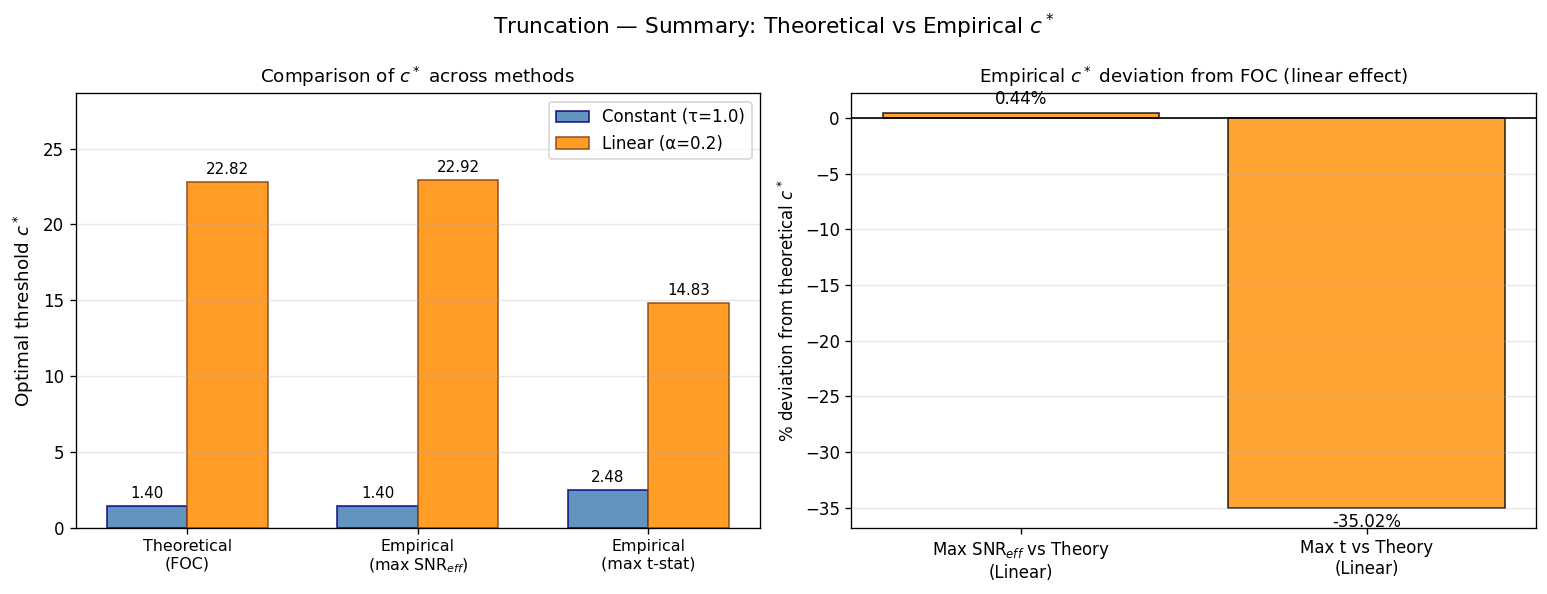


── Final Summary ──
Constant effect (τ=1.0):
  Theory c*=1.4001 | SNR c*=1.3964 (-0.26%) | t c*=2.4810 (+77.21%)
Linear effect (α=0.2):
  Theory c*=22.8226 | SNR c*=22.9220 (+0.44%) | t c*=14.8290 (-35.02%)


In [7]:
# ── Summary ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Truncation — Summary: Theoretical vs Empirical $c^*$', fontsize=13)

methods = ['Theoretical\n(FOC)', 'Empirical\n(max SNR$_{eff}$)', 'Empirical\n(max t-stat)']
x_pos   = np.arange(len(methods))
w       = 0.35

vals_const = [
    c_star_theory_const if c_star_theory_const else c_star_snr_const,
    c_star_snr_const,
    c_star_tstat_const,
]
vals_lin = [c_star_theory_lin, c_star_snr_lin, c_star_tstat_lin]

ax = axes[0]
b1 = ax.bar(x_pos - w/2, vals_const, w, label=f'Constant (τ={TAU})',
            color='steelblue', alpha=0.85, edgecolor='navy')
b2 = ax.bar(x_pos + w/2, vals_lin,   w, label=f'Linear (α={ALPHA})',
            color='darkorange', alpha=0.85, edgecolor='saddlebrown')
ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.2f', padding=3, fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(methods, fontsize=9.5)
ax.set_ylabel('Optimal threshold $c^*$', fontsize=11)
ax.set_title('Comparison of $c^*$ across methods', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ymax = max(max(vals_const), max(vals_lin)) * 1.25
ax.set_ylim(0, ymax)

# % deviation from theory (linear only since constant is boundary)
ax2 = axes[1]
if c_star_theory_lin:
    dev_snr_lin   = 100*(c_star_snr_lin   - c_star_theory_lin) / c_star_theory_lin
    dev_tstat_lin = 100*(c_star_tstat_lin - c_star_theory_lin) / c_star_theory_lin
else:
    dev_snr_lin = dev_tstat_lin = 0

cats  = ['Max SNR$_{eff}$ vs Theory\n(Linear)', 'Max t vs Theory\n(Linear)']
devs  = [dev_snr_lin, dev_tstat_lin]
cols  = ['darkorange', 'darkorange']
bars  = ax2.bar(cats, devs, color=cols, alpha=0.8, edgecolor='k')
ax2.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax2.axhline(0, color='k', lw=1)
ax2.set_ylabel('% deviation from theoretical $c^*$', fontsize=10)
ax2.set_title('Empirical $c^*$ deviation from FOC (linear effect)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('truncation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Final Summary ──")
print(f"Constant effect (τ={TAU}):")
if c_star_theory_const:
    dc = 100*(c_star_snr_const - c_star_theory_const)/c_star_theory_const
    dt = 100*(c_star_tstat_const - c_star_theory_const)/c_star_theory_const
    print(f"  Theory c*={c_star_theory_const:.4f} | SNR c*={c_star_snr_const:.4f} ({dc:+.2f}%) | t c*={c_star_tstat_const:.4f} ({dt:+.2f}%)")
else:
    print(f"  Theory: BOUNDARY (no interior optimum under effective-N SNR)")
    print(f"  Empirical max-SNR_eff c*={c_star_snr_const:.4f},  max-t c*={c_star_tstat_const:.4f}")
print(f"Linear effect (α={ALPHA}):")
if c_star_theory_lin:
    dc = 100*(c_star_snr_lin - c_star_theory_lin)/c_star_theory_lin
    dt = 100*(c_star_tstat_lin - c_star_theory_lin)/c_star_theory_lin
    print(f"  Theory c*={c_star_theory_lin:.4f} | SNR c*={c_star_snr_lin:.4f} ({dc:+.2f}%) | t c*={c_star_tstat_lin:.4f} ({dt:+.2f}%)")

## Key Structural Differences: Capping vs Truncation

| | **Capping** | **Truncation** |
|---|---|---|
| Data used | All $N$ observations (no loss) | Only $X_i\le c$, $Y_i\le c$ (data lost) |
| $\mu(c)$ derivative | $\bar{F}(c)$ | $r(c)\cdot(c-\mu(c))$ &nbsp; (*reverse hazard rate*) |
| $V(c)$ derivative | $2\bar{F}(c)(c-\mu(c))$ | $r(c)[(c-\mu(c))^2-V(c)]$ |
| FOC RHS | $f\cdot\bar{F}(c)\cdot(c-\mu(c))$ | $f\cdot r(c)\cdot[(c-\mu(c))^2-2V(c)]$ |
| Constant effect: interior $c^*$? | **Yes** (both effects have interior optima) | **Conditional** (exists when $F(c)$ factor included) |
| Linear effect: interior $c^*$? | **Yes** | **Yes** |

**The $F(c)$ factor matters for truncation:** Unlike capping (which uses all $N$ observations),
truncation loses $N(1-F(c))$ observations. The SNR must account for this via a $\sqrt{F(c)}$ multiplier,
which changes the optimality condition and ensures interior solutions exist for both effect types.